In [ ]:
"""
@author Thomas Torres
CSC 461/ DSP 461, LocalMAP Silhouette Evaluations, SVM Evaluations,
and recreations of Visualizations.

------------------------------------------------------------------------------
                                          Potential Bugs:

Big warning, I did not use this particular code in this file to determine my figures. I used an earlier version I manually modified
to fit the need of what I was doing to handle my code. The first cell executes fine, and i cannot test
the other 2 cells because of how long they take. Judging by the fact that I generated all of the figures, and the
evaluation and experiment functions both produced accurate figures, I think they probably work after iterating through a lot of data.
If they do not, the code is fairly easy to fix up.

When evaluating the models, I used a modified version of this code. I had it running across 6 different colab instances.
This is a version which is meant to streamline all of them. Since I did not use this precise code to run
all of my models, there is a higher chance of running into bugs or issues. If you plan to run this code expecting it to work and be a
quick hour or two hour execution, you are sorely mistaken. This takes upwards of 20 hours to
execute in full using this single threaded condensed program.

------------------------------------------------------------------------------
                                          Instructions:
You need to get the data file I have on the GitHub under data.zip, otherwise this will not work.
Run only in Colab. This code is meant to only be run in this environment and will NOT work otherwise. Ideally, executing each cell
by hitting run all should work out of the box, if you add the data correctly.

To begin evaluations, start by adding the zipped data file to the root directory.
Unzip it.

Specify its name here, for our evaluations we used 'data.zip'.
Check the GitHub repo for this file, and unzip it here.

Once the data is unzipped, be sure that there is a file named 'mnist.npy' and 'fmnist.npy'.
If there is a 'mnist_images.npy' or "fmnist.mpy', rename them appropriately to be mnist.npy and fmnist.npy
respectively.
"""

ZIPPED_FILE_NAME : str = "data.zip"
#unzip file
!unzip "data.zip" -d "data"
DATA_FILE : str = "data/data/"

#all imports used in the project, unfortunately we could not get LargeVIS to work
#it has a fairly difficult installation process without much documentation.
import numpy as np
from sklearn import datasets
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.metrics import silhouette_score
from scipy.stats import norm
import time
import os

#install all relevant libraries used in the paper
libraries=['phate','opentsne',
'umap-learn',
'hnne',
'contrastive-ne',
'trimap',
'tqdm',
'pacmap']
for lib in libraries:
  !pip install {lib}

Archive:  data.zip
replace data/data/20NG.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: Requirement already satisfied: phate in /usr/local/lib/python3.12/dist-packages (2.0.0)


mkdir: cannot create directory ‘embeddings’: File exists
mkdir: cannot create directory ‘embeddings/PaCMAP’: File exists
mkdir: cannot create directory ‘embeddings/LocalMAP’: File exists
mkdir: cannot create directory ‘embeddings/TSNE’: File exists
mkdir: cannot create directory ‘embeddings/UMAP’: File exists
mkdir: cannot create directory ‘embeddings/HNNE’: File exists
mkdir: cannot create directory ‘embeddings/InfoNCE’: File exists
mkdir: cannot create directory ‘embeddings/NegTSNE’: File exists
mkdir: cannot create directory ‘embeddings/NCVi’: File exists
mkdir: cannot create directory ‘embeddings/TriMAP’: File exists
mkdir: cannot create directory ‘embeddings/PHATE’: File exists
mkdir: cannot create directory ‘embeddings/PCA’: File exists
Evaluating: PaCMAP


KeyboardInterrupt: 

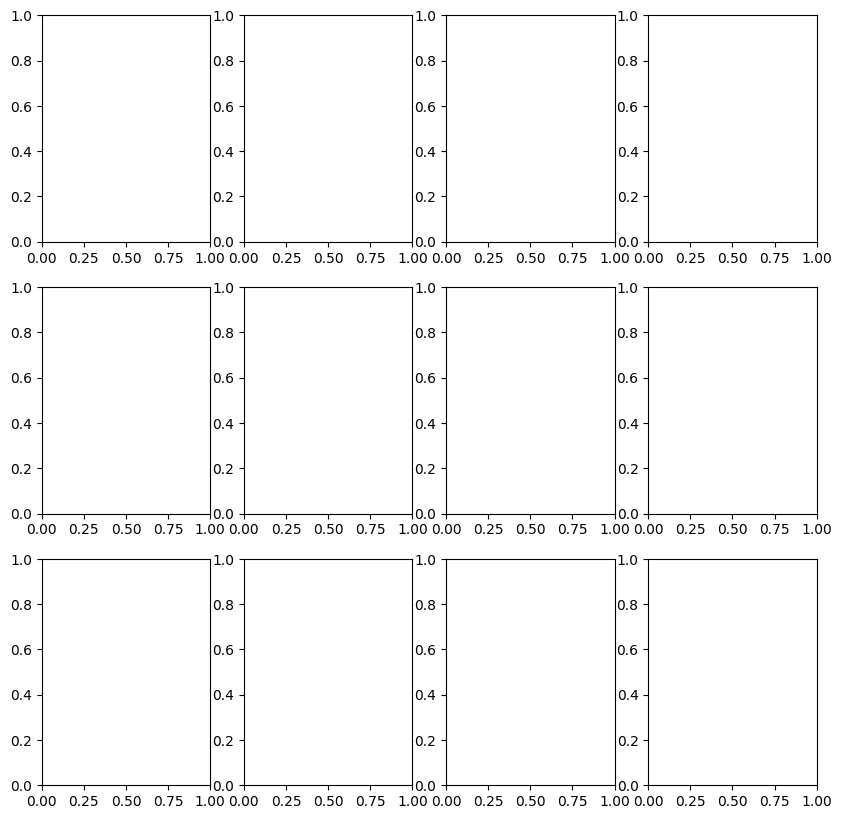

In [6]:
"""
Performs manipulations on data so that the evaluation function can use it without any issue.
This function is a slightly modified version of a function used in the LocalMAP GitHub repo.
"""
def data_prep(data):
    #default path if you use the data.zip folder included in the repo
    data_path = './data/data'
    if data == "mnist":
        X = np.load(data_path + '/mnist.npy', allow_pickle=True).reshape(70000, 28 * 28)
        labels = np.load(data_path + '/mnist_labels.npy', allow_pickle=True)
    elif data == "fmnist":
        X = np.load(data_path + '/fmnist.npy', allow_pickle=True).reshape(70000, 28 * 28)
        labels = np.load(data_path + '/fmnist_labels.npy', allow_pickle=True)
    elif data == "USPS":
        X = np.load(data_path + '/USPS.npy', allow_pickle=True)
        labels = np.load(data_path + '/USPS_labels.npy', allow_pickle=True)
    elif data == "20NG":
        X = np.load(data_path + '/20NG.npy', allow_pickle=True)
        labels = np.load(data_path + '/20NG_labels.npy', allow_pickle=True)
    elif data == "coil_20":
        X = np.load(data_path + '/coil_20.npy', allow_pickle=True).reshape(1440, 128 * 128)
        labels = np.load(data_path + '/coil_20_labels.npy', allow_pickle=True)
    elif data == "kang":
        X = np.load(data_path + "/kang_log_pca.npy", allow_pickle=True)
        labels = np.load(data_path + "/kang_labels.npy", allow_pickle=True)
    elif data =="CBMC":
        X = np.load(data_path + "/CBMC.npy", allow_pickle=True)
        labels = np.load(data_path + "/CBMC_labels.npy", allow_pickle=True)
    elif data == "human_cortex":
        X = np.load(data_path + "/human_cortex.npy", allow_pickle=True)
        labels = np.load(data_path + "/human_cortex_labels.npy", allow_pickle=True)
    elif data == "seurat":
        X = np.load(data_path + "/seurat_data.npy", allow_pickle=True)
        labels = np.load(data_path + "/seurat_label.npy", allow_pickle=True)
    return X, labels

"""Function that is slightly modified code from the LocalMAP repository for evaluating
different models on data. Produces and saves an embedding to a specific directory.
@param model_name - name of the model we want to evaluate data on
@param data_set_name - what to save the embedded data as
@i - index of the saved data
@X - the data we want to embed
@return Returns the transformed data
"""
def evaluate_model(model_name : str, data_set_name : str, i : int, X,y ):
    if model_name == 'PaCMAP':
        import pacmap
        model = pacmap.PaCMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "LocalMAP":
        from pacmap import LocalMAP
        model = LocalMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "TSNE":
        # import openTSNE
        # model = openTSNE.TSNE(n_jobs=-1)
        from sklearn.manifold import TSNE
        model = TSNE()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "UMAP":
        import umap
        model = umap.UMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "HNNE":
        import hnne
        model = hnne.HNNE()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "InfoNCE":
        import cne
        model = cne.CNE()
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "NegTSNE":
        import cne
        model = cne.CNE(loss_mode="neg")
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "NCVi":
        import cne
        model = cne.CNE(loss_mode="nce",optimizer="adam")
        start_time = time.time()
        X_trans = model.fit_transform(X.astype(float))
        total_time = time.time()-start_time
    elif model_name == "TriMAP":
        import trimap
        model = trimap.TRIMAP()
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "PHATE":
        import phate
        model = phate.PHATE(n_jobs=-1)
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time
    elif model_name == "PCA":
        from sklearn.decomposition import PCA
        model = PCA(n_components=2)
        start_time = time.time()
        X_trans = model.fit_transform(X)
        total_time = time.time()-start_time

    # save the embedding into the embedding folder
    #was supposed to this originally but i decided to save it in the function that
    #calls this function
    return (X_trans,total_time)

"""Evaluation Function for a specific dataset"""
def eval_data(data_name : str,data_set,labels):

    models=["PaCMAP","LocalMAP","TSNE","UMAP","HNNE","InfoNCE","NegTSNE","NCVi","TriMAP","PHATE","PCA"]
    fig, axes = plt.subplots(3, 4, figsize=(10, 10))
    axes = axes.flatten()
    for i in range(len(models)):
      total_time = 0
      print(f"Evaluating: {models[i]}")
      for j in range(10):
            model_name = models[i]
            SAVE_DIR : str = f"embeddings/{model_name}/{data_name}_embedding_{j+1}.npy"
            #10 diff trials with each model
            X_trans,time_increment=evaluate_model(model_name, data_name, i,data_set,labels)
            total_time+=time_increment
            #save embedding
            np.save(SAVE_DIR,X_trans)

            #if we are on last iteration of j then render
            if(j+1==10):
              ax = axes[i]
              ax.scatter(X_trans[:, 0], X_trans[:, 1], cmap="Spectral", c=y, s=1)
              ax.set_title(f"{model_name}")
              ax.set_xlabel("X")
              ax.set_ylabel("Y")
          #I kept running into errors with HNNE for low quantities of basis vectors
          #when considering transformed data, so this is just to handle it
      #save embedding

    fig.suptitle(data_name, fontsize=16, fontweight='bold')
    #show layout
    plt.tight_layout()
    plt.legend()
    plt.show()

    #save resulting figure
    plt.savefig(f"{data_name}.png")


#set up the embeddings folder and subfolders
!mkdir embeddings
models=["PaCMAP","LocalMAP","TSNE","UMAP","HNNE","InfoNCE","NegTSNE","NCVi","TriMAP","PHATE","PCA"]
for model in models:
  !mkdir embeddings/{model}
total_times = {}
#finally data sets on it
file_name_roots = ["20NG","USPS","coil_20","fmnist","mnist"]
for root in file_name_roots:
    data_file_name : str = f"{DATA_FILE}{root}.npy"
    label_file_name : str = f"{DATA_FILE}{root}_labels.npy"

    #load data
    X,y=data_prep(root)

    #evaluate and produce image
    eval_data(root,X,y)




In [14]:
"""This step is meant to perform all of the evaluations."""
#Here we evaluate the silhouette scores of all of the models
import os
import numpy as np
import pickle
import numba
import scipy.stats
import math

# from run_script import data_prep
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import scale

"""Get mean, and upper and lower bound of the run"""
def get_confidence_intervals_mean_of_runs(score_set : list[float]):
    mean_score = np.mean(score_set)
    std_score = np.std(score_set, ddof=1) # ddof=1 for sample standard deviation
    n = len(score_set)

    # Calculate standard error of the mean
    sem = std_score / np.sqrt(n)
    confidence_level = 0.95
    lower_bound, upper_bound = norm.interval(confidence_level, loc=mean_score, scale=sem)
    return (lower_bound,upper_bound,mean_score,sem)

"""The SVM evaluation code comes out of the LocalMAP repository"""
def svm_eval(X, y, n_splits=10, **kwargs):
    '''
    This is a function that is used to evaluate the lower dimension embedding.
    An accuracy is calculated by an SVM with rbf kernel.
    Input:
        X: A numpy array with the shape [N, k]. The lower dimension embedding
           of some dataset. Expected to have some clusters.
        y: A numpy array with the shape [N, 1]. The labels of the original
           dataset.
        kwargs: Any keyword argument that is send into the SVM.
    Output:
        acc: The (avg) accuracy generated by an SVM with rbf kernel.
    '''
    X = scale(X)
    skf = StratifiedKFold(n_splits=n_splits)
    sum_acc = 0
    max_acc = n_splits
    for train_index, test_index in skf.split(X, y):
        clf = SVC(**kwargs)
        clf.fit(X[train_index], y[train_index])
        acc = clf.score(X[test_index], y[test_index])
        sum_acc += acc
    avg_acc = sum_acc/max_acc
    return avg_acc


"""Evaluates Silhouette Score Given a set of embeddings produced by a model.
Prints everything directly to the console if specified, otherwise saves all relevant data into 2 files
@param path - the directory all of the embeddings are stored in
@param output_data_file_name - the root name for the SVM file and silhouette scores file
@param searched_files - the names of the files we want to evaluate
@param do_prints - if resulting computations should be printed to the console or not
"""
def evaluate_embedding_scores(path : str, output_data_file_name : str, searched_files : list[str], do_prints : bool):


    method_and_silhou = {}
    method_and_svm = {}
    for folder in os.listdir(path):
        #folder created by jupyter notebooks containing temporary info, ignore
        if folder !=".ipynb_checkpoints":
            sub_directory = f"{path}/{folder}/"
            print("-"*80)
            print(f"EVALUATING {folder}")
            silhou_score=[]
            svm_score = []

            #iterate over all sought after file types
            for searched_file in searched_files:
                print(searched_file)
                X,y=data_prep(searched_file)
                silhou_score=[]
                svm_score = []
                print(f"For: {searched_file}")
                # look through each embedding corresponding to it
                #we expect 10, since hence this

                for i in range(10):
                    #look for appropriate embedding given name
                    file_name : str = f"{sub_directory}{searched_file}_embedding_{i+1}.npy"
                    print(file_name)
                    embedding=np.load(file_name)
                    silhou_score.append(silhouette_score(embedding, y))
                    svm_score.append(svm_eval(embedding, y))

                #calculate relevant summary stats
                std_score = np.std(silhou_score, ddof=1)
                n = len(silhou_score)

                #get assosciated silhou and svm scores add to respective dicts
                silhouLower,silhouUpper,silhouMean,silhouSEM=get_confidence_intervals_mean_of_runs(silhou_score)
                svmLower,svmUpper,svmMean,svmSEM=get_confidence_intervals_mean_of_runs(svm_score)

                #handle NAN errors
                if(math.isnan(silhouSEM)):
                  silhouSEM=0
                if(math.isnan(svmSEM)):
                  svmSEM=0

                silhouMean=round(np.float64(silhouMean),2)
                svmMean=round(svmMean,2)

                #work dict for silhouette score
                if(folder in method_and_silhou):
                    method_and_silhou[folder]+=f" & {silhouMean} $\\pm$ {round(silhouSEM,2)} "
                else:
                    method_and_silhou[folder]=f"{folder} & {silhouMean} $\\pm$ {round(silhouSEM,2)} "

                #work dict for the SVM score
                if(folder in method_and_svm):
                    method_and_svm[folder]+=f" & {svmMean} $\\pm$ {round(svmSEM,2)} "
                else:
                    method_and_svm[folder]=f"{folder} & {svmMean} $\\pm$ {round(svmSEM,2)} "

                #only print if specified by user, can clutter console a lot
                if(do_prints):
                    print(f"Silhouette Score: {silhouMean}")
                    print(f"Silhouette Lower Bound: {silhouLower}")
                    print(f"Silhouette Upper Bound: {silhouUpper}")
                    print(f"Silhouette SEM: {silhouSEM}")

                    print(f"SVM Score: {svmMean}")
                    print(f"SVM Lower Bound: {svmLower}")
                    print(f"SVM Upper Bound: {svmUpper}")
                    print(f"SVM SEM: {svmSEM}")

                    print("-"*80)

    #originally, i triied to be clever and get everything to output to a nice data
    #matrix that you could plug into text and have working, but it failed
    #if you are familiar with tex i would encourage you to look at this section, otherwise
    #it's just an artifact in the code
    #save to corresponding output folders
    #with open(f"{output_data_file_name}_silhouette_scores.txt",'w') as file:
    #    for key, value in method_and_silhou.items():
    #        file.write(f"{value} \\\\ \\hline \n")
    #with open(f"{output_data_file_name}_svm_scores.txt",'w') as file:
    #    for key, value in method_and_svm.items():
    #        file.write(f"{value} \\\\ \\hline \n")

#evaluate k=10, k=50, k=100 many eigen-vectors

#evaluates all of the above embeddings
embeddings_to_consider=["fmnist","20NG","USPS","coil_20","mnist"]
evaluate_embedding_scores("./embeddings","report_output_tex",embeddings_to_consider, True)


--------------------------------------------------------------------------------
EVALUATING TSNE
fmnist
For: fmnist
./embeddings/TSNE/fmnist_embedding_1.npy


KeyboardInterrupt: 